In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Type, Optional, List, Union

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import ElasticNet
from sklearn.metrics import make_scorer
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from DataFit import *

### Initialize the object

In [2]:
df_train = pd.read_csv('../train.csv')
df_train.head()

,id,spacegroup,number_of_total_atoms,percent_atom_al,percent_atom_ga,percent_atom_in,lattice_vector_1_ang,lattice_vector_2_ang,lattice_vector_3_ang,lattice_angle_alpha_degree,lattice_angle_beta_degree,lattice_angle_gamma_degree,formation_energy_ev_natom,bandgap_energy_ev
0,1,33,80.0,0.6250,0.3750,0.000,9.9523,8.5513,9.1775,90.0026,90.0023,90.0017,0.0680,3.4387
1,2,194,80.0,0.6250,0.3750,0.000,6.1840,6.1838,23.6287,90.0186,89.9980,120.0025,0.2490,2.9210
2,3,227,40.0,0.8125,0.1875,0.000,9.7510,5.6595,13.9630,90.9688,91.1228,30.5185,0.1821,2.7438
3,4,167,30.0,0.7500,0.0000,0.250,5.0036,5.0034,13.5318,89.9888,90.0119,120.0017,0.2172,3.3492
4,5,194,80.0,0.0000,0.6250,0.375,6.6614,6.6612,24.5813,89.9960,90.0006,119.9893,0.0505,1.3793


List of variables

In [3]:
output_list = ['formation_energy_ev_natom', 'bandgap_energy_ev']
categorical_list = ['spacegroup']
input_list = [var for var in df_train.columns.to_list() if var not in output_list+categorical_list+['id','number_of_total_atoms']]

Create an object

In [4]:
DF = DataFit(df_train, continous_inputs=input_list, categorical_inputs=categorical_list, output='bandgap_energy_ev', use_PCA = False)

Fit ALL

In [5]:
DF.FitAll()

c:\Users\joe48\Anaconda3\envs\cmpinf\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.640e+01, tolerance: 1.925e-01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\Users\joe48\Anaconda3\envs\cmpinf\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.853e+01, tolerance: 1.952e-01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers impl

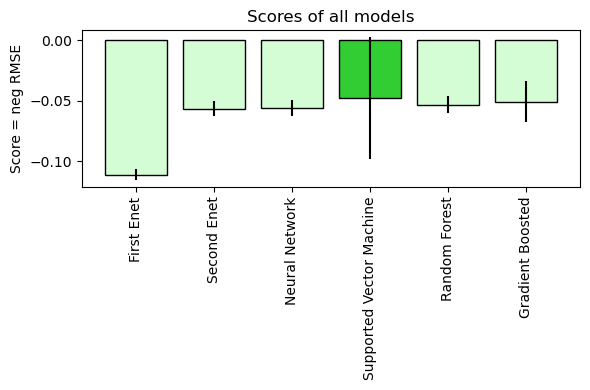

In [6]:
DF.PlotAll()

In [18]:
DF.DataFrameForEachModel()[5]

('Gradient Boosted',
     learning_rate  max_depth  n_estimators  mean_test_score  std_test_score
 0            0.02        1.0          25.0    -6.694422e-01    1.710746e-02
 1            0.02        1.0         100.0    -3.137287e-01    5.716329e-03
 2            0.02        1.0         250.0    -1.403448e-01    4.334718e-03
 3            0.02        1.0         400.0    -9.716655e-02    4.760147e-03
 4            0.02        3.0          25.0    -4.990236e-01    1.300199e-02
 5            0.02        3.0         100.0    -1.164727e-01    7.010159e-03
 6            0.02        3.0         250.0    -5.675007e-02    8.302038e-03
 7            0.02        3.0         400.0    -5.197972e-02    8.210972e-03
 8            0.02        6.0          25.0    -4.179702e-01    1.335442e-02
 9            0.02        6.0         100.0    -7.464257e-02    6.375144e-03
 10           0.02        6.0         250.0    -5.468491e-02    8.588082e-03
 11           0.02        6.0         400.0    -5.53242

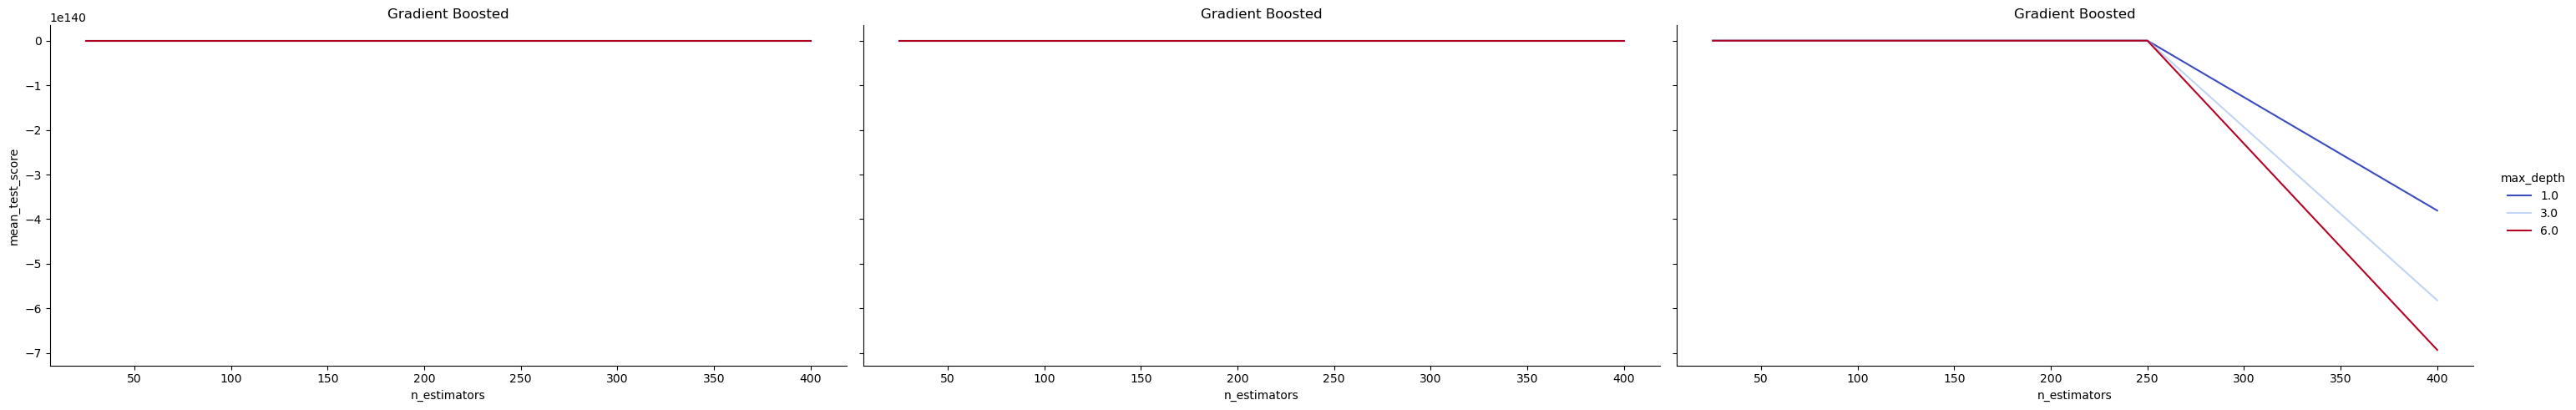

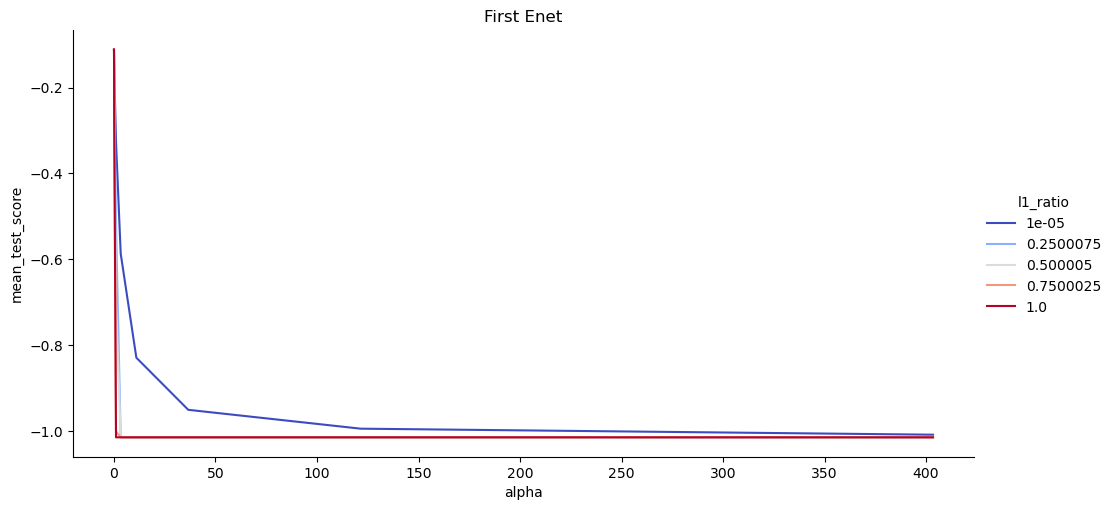

In [9]:
sns.relplot(data = DF.DataFrameForEachModel()[0][1], x='alpha', y='mean_test_score', hue='l1_ratio',
            palette='coolwarm', kind='line', aspect=2.).set(title = DF.DataFrameForEachModel()[0][0])

plt.show()

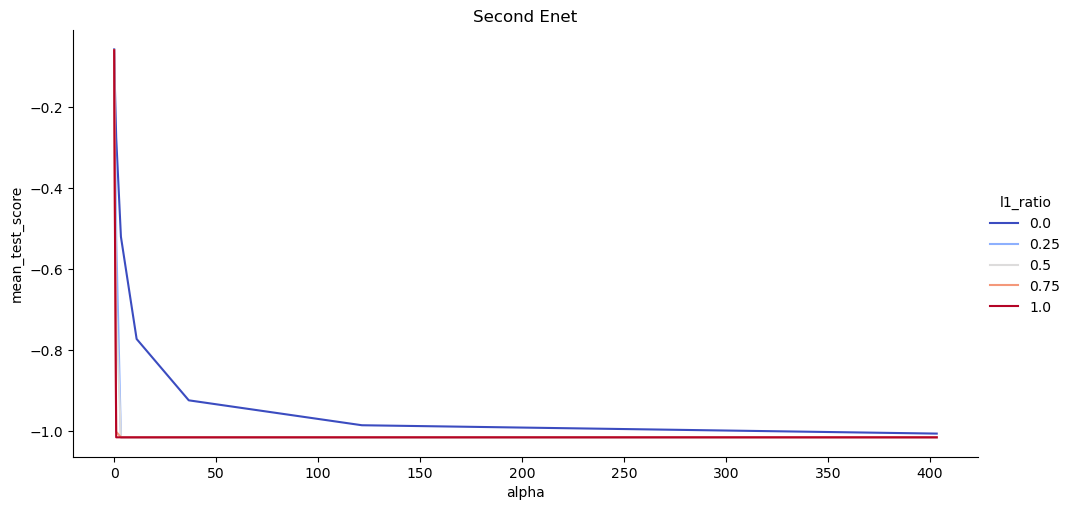

In [10]:
sns.relplot(data = DF.DataFrameForEachModel()[1][1], x='alpha', y='mean_test_score', hue='l1_ratio',
            palette='coolwarm', kind='line', aspect=2.).set(title = DF.DataFrameForEachModel()[1][0])

plt.show()

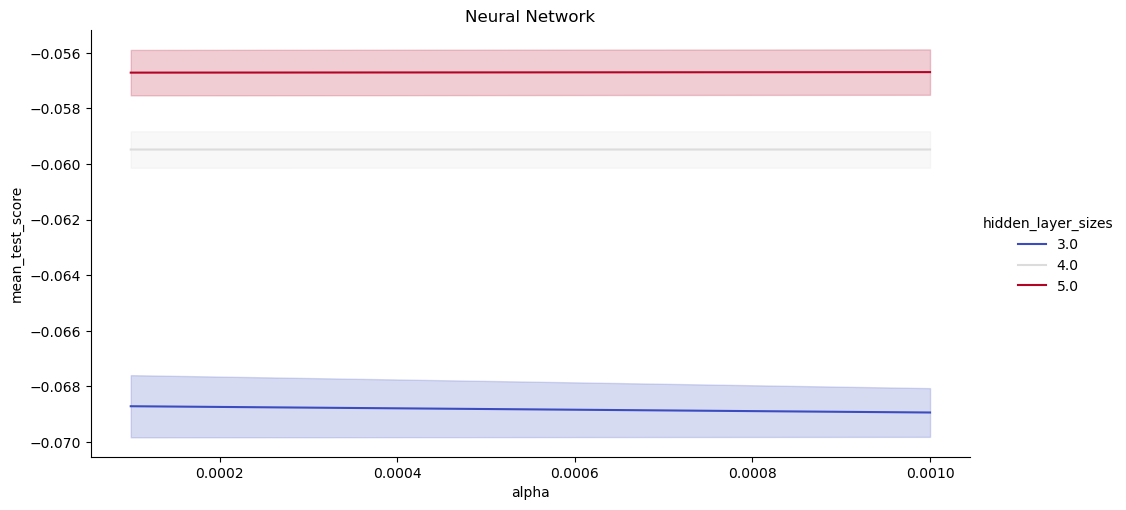

In [11]:
sns.relplot(data = DF.DataFrameForEachModel()[2][1], x='alpha', y='mean_test_score', hue='hidden_layer_sizes',
            palette='coolwarm', kind='line', aspect=2.).set(title = DF.DataFrameForEachModel()[2][0])

plt.show()

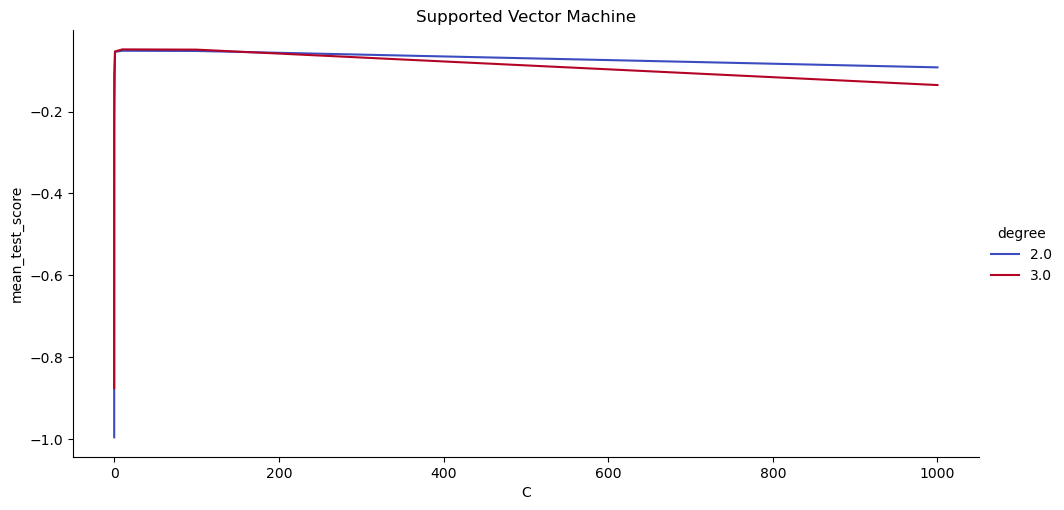

In [12]:
sns.relplot(data = DF.DataFrameForEachModel()[3][1], x='C', y='mean_test_score', hue='degree',
            palette='coolwarm', kind='line', aspect=2.).set(title = DF.DataFrameForEachModel()[3][0])

plt.show()

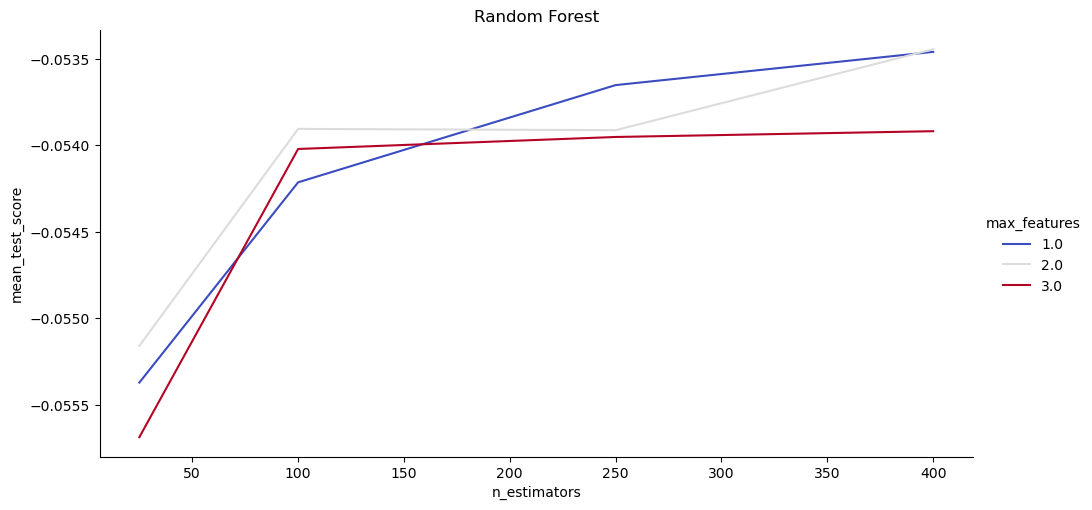

In [17]:
sns.relplot(data = DF.DataFrameForEachModel()[4][1], x='n_estimators', y='mean_test_score', hue='max_features',
            palette='coolwarm', kind='line', aspect=2.).set(title = DF.DataFrameForEachModel()[4][0])

plt.show()

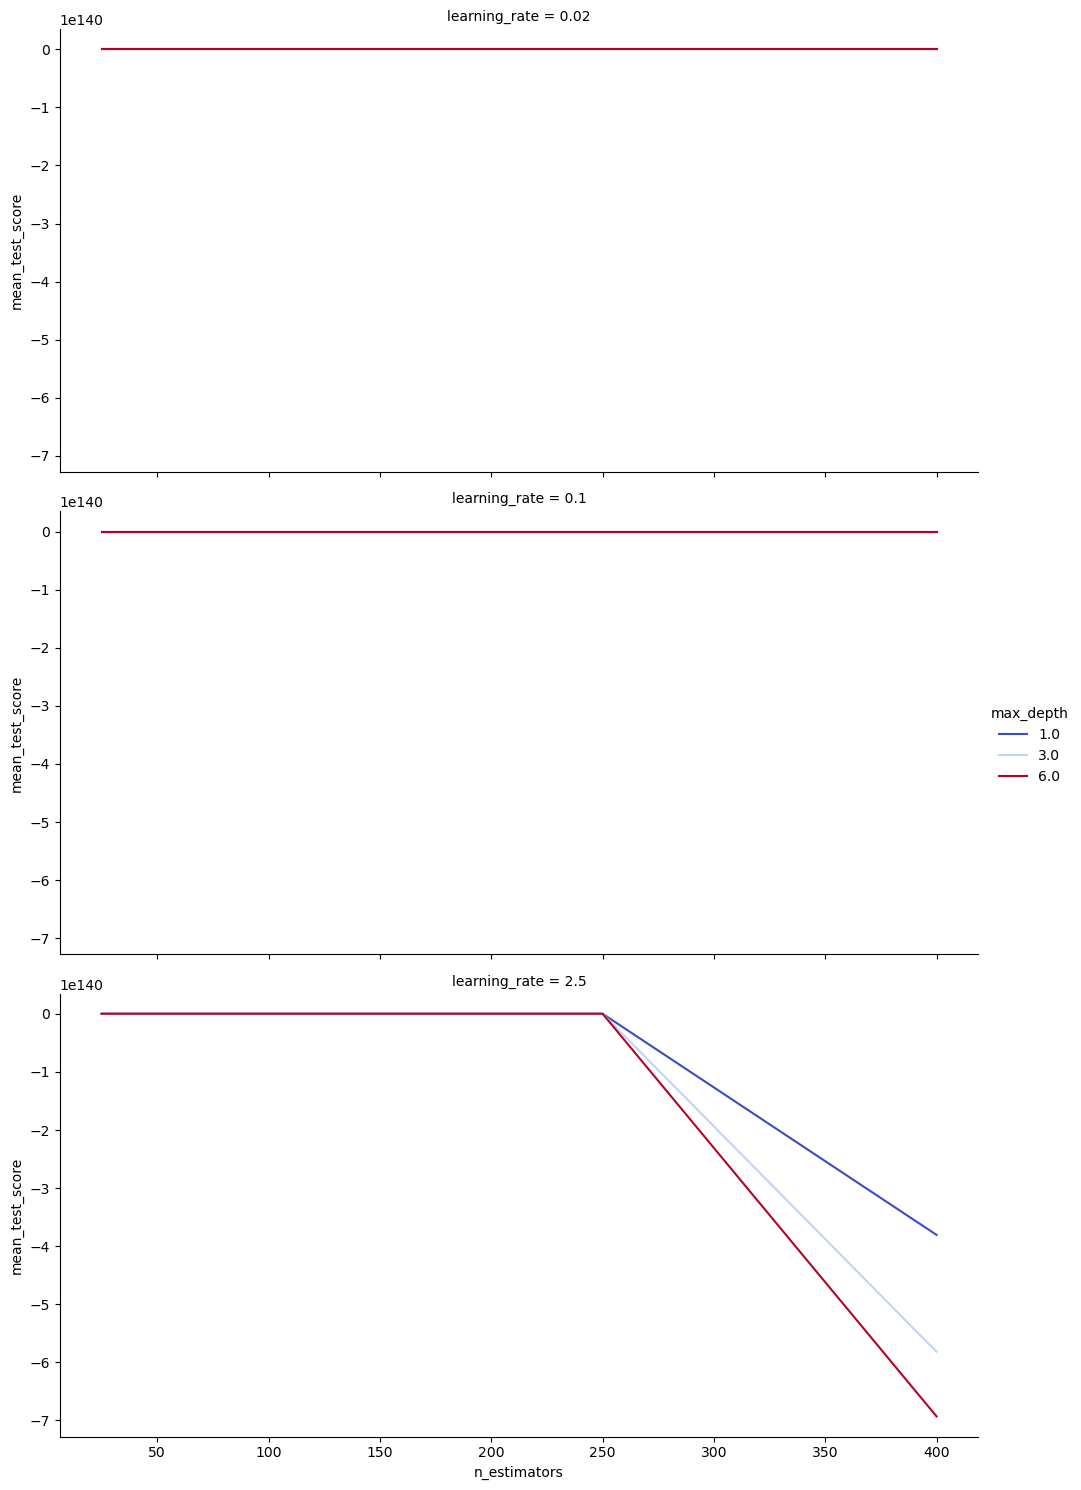

In [25]:
sns.relplot(data = DF.DataFrameForEachModel()[5][1], x='n_estimators', y='mean_test_score', hue='max_depth', row = 'learning_rate',
            palette='coolwarm', kind='line', aspect=2.)

plt.show()